## Feature Searcher for Tomorrow

In [ ]:
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import umap
from umap.umap_ import nearest_neighbors
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

warnings.filterwarnings("ignore")

df = pd.read_csv("bobbynamboy3.csv") # should take 4 mins

/Users/shreyanakum/Documents/Workshops-Code-2627/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## Cleanup
netid_col = [c for c in df.columns if c.startswith("UCI NetID")][0]
llm_col = [c for c in df.columns if c.startswith("Favorite LLM")][0]
df = df.drop(columns=["Timestamp", "Full Name", netid_col]).dropna().reset_index(drop=True)

for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

grade_order = ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
y = df["Grade Level"].map({g: i for i, g in enumerate(grade_order)}).values

## Who is who
numeric_cols = ["Level of ML understanding",
                "Level of Python programming skills",
                "Level of C++ programming skills"]

yes_no_cols = ["Have you taken CS 171?",
               "Have you previously attended an AI Club meeting?"]

categorical_cols = ["Major", "Birth Month", "Birth State (Location)", llm_col]

groups = {}
for c in numeric_cols:
    groups[c] = df[[c]].astype(float)

for c in yes_no_cols:
    groups[c] = df[c].map({"Yes": 1, "No": 0}).to_frame().astype(float)

for c in categorical_cols:
    groups[c] = pd.get_dummies(df[c], prefix=c, dtype=float)

## Search settings
N_NEIGHBORS_UMAP = 5
K_VALUES = [3, 5] # KNN k values to try
cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=42)

names = list(groups)
results = []
for r in range(1, len(names) + 1):
    for combo in itertools.combinations(names, r):
        X = np.hstack([groups[n].values for n in combo])
        X = StandardScaler().fit_transform(X)

        knn = nearest_neighbors(X, n_neighbors=N_NEIGHBORS_UMAP, metric="euclidean", metric_kwds=None, angular=False, random_state=42)
        emb = umap.UMAP(n_neighbors=N_NEIGHBORS_UMAP, precomputed_knn=knn, random_state=42).fit_transform(X)

        for k in K_VALUES:
            acc = cross_val_score(KNeighborsClassifier(n_neighbors=k), emb, y, cv=cv).mean()
            results.append({"accuracy": acc, "k": k, "n_features": len(combo), "features": " | ".join(combo)})

res = (pd.DataFrame(results).sort_values(["accuracy", "n_features"], ascending=[False, True]).reset_index(drop=True))

res.to_csv("feature_search_results.csv", index=False)

baseline = np.bincount(y).max()/len(y)

print(f"Majority-class baseline: {baseline}")

print(res.head(10).to_string())

Majority-class baseline: 0.34285714285714286
   accuracy  k  n_features                                                                                                                                                                                                                                                    features
0  0.606566  3           4                                                                                                                  Level of ML understanding | Level of Python programming skills | Have you taken CS 171? | Have you previously attended an AI Club meeting?
1  0.588384  5           5                                                                                   Level of Python programming skills | Level of C++ programming skills | Have you taken CS 171? | Have you previously attended an AI Club meeting? | Birth State (Location)
2  0.545960  5           6                              Level of Python programming skills | Level of C++ programming 


Selected combo (CV acc 0.54, k=5):
  - Level of ML understanding
  - Level of Python programming skills
  - Level of C++ programming skills
  - Have you taken CS 171?
  - Have you previously attended an AI Club meeting?
  - Birth State (Location)
  - Favorite LLM (e.g., ChatGPT, Claude, Gemini, Grok)


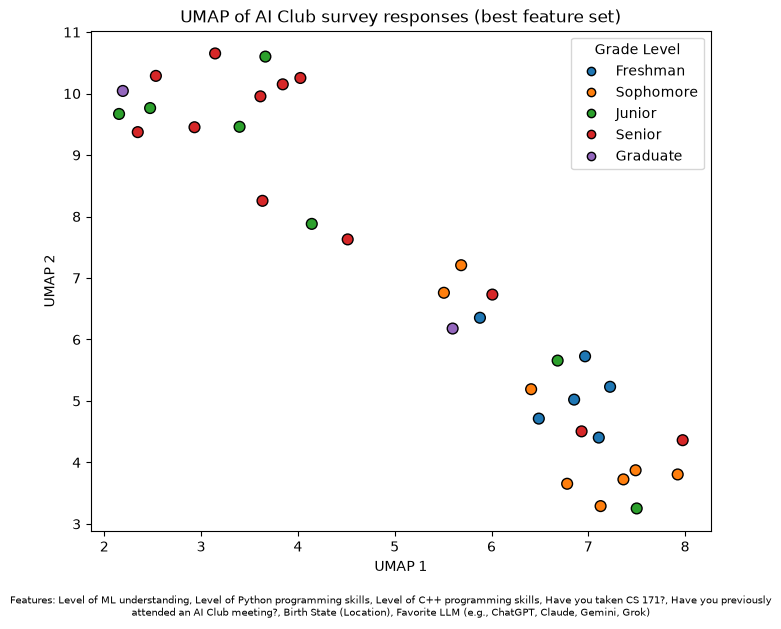

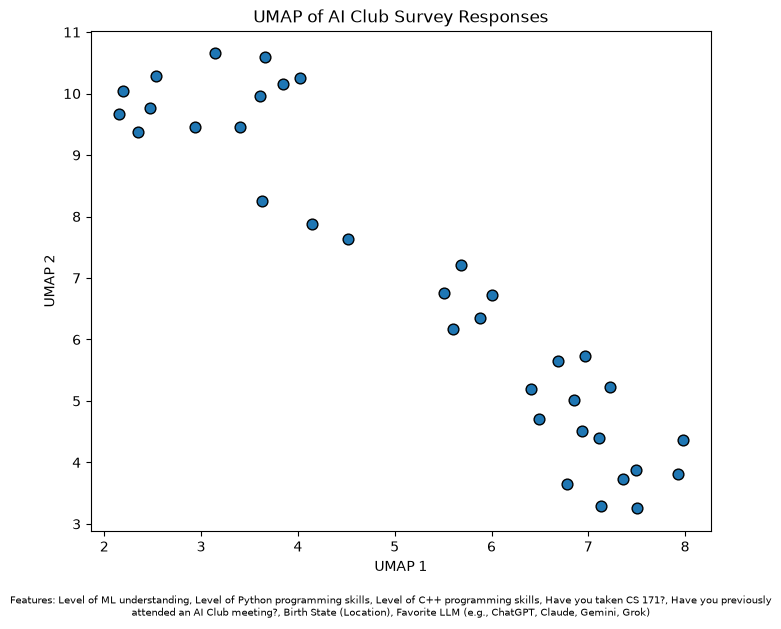

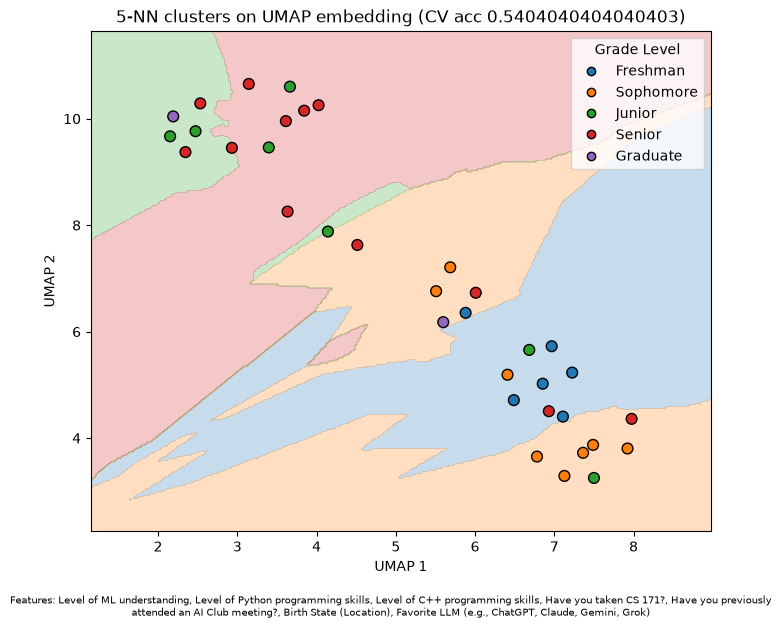

In [8]:
## Plots for the best combo

best = res.iloc[4]

best_features = best["features"].split(" | ")
k = int(best["k"])
print(f"\nSelected combo (CV acc {best['accuracy']:.2f}, k={k}):")
for f in best_features:
    print("  -", f)
 
X = np.hstack([groups[n].values for n in best_features])
X = StandardScaler().fit_transform(X)
 
## UMAP Plot (precomputed k-nearest neighbors)
knn = nearest_neighbors(X, n_neighbors=N_NEIGHBORS_UMAP, metric="euclidean", metric_kwds=None, angular=False, random_state=42)
embedding = umap.UMAP(n_neighbors=N_NEIGHBORS_UMAP, precomputed_knn=knn, random_state=42).fit_transform(X)
 
cmap = ListedColormap(plt.cm.tab10.colors[:len(grade_order)])
present = sorted(set(y))  # only legend entries for grades that exist
handles = [plt.Line2D([], [], marker="o", ls="", color=cmap(i), mec="k", label=grade_order[i]) for i in present]
subtitle = ", ".join(best_features)
 
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap=cmap, vmin=0, vmax=len(grade_order) - 1, s=60, edgecolor="k")
ax.legend(handles=handles, title="Grade Level")
ax.set_title("UMAP of AI Club survey responses (best feature set)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
fig.text(0.5, -0.02, f"Features: {subtitle}", ha="center", fontsize=7, wrap=True)
fig.savefig("umap_plot_best.pdf", bbox_inches="tight")
 
## UMAP Plot, no labels: same embedding, plain points (no grade coloring/legend) for PRINTING
fig_plain, ax_plain = plt.subplots(figsize=(8, 6.5))
ax_plain.scatter(embedding[:, 0], embedding[:, 1], color="tab:blue", s=60, edgecolor="k")
ax_plain.set_title("UMAP of AI Club Survey Responses")
ax_plain.set_xlabel("UMAP 1")
ax_plain.set_ylabel("UMAP 2")
fig_plain.text(0.5, -0.02, f"Features: {subtitle}", ha="center", fontsize=7, wrap=True)
fig_plain.savefig("umap_plot_printing.pdf", bbox_inches="tight")
 
## KNN on UMAP Output
knn_clf = KNeighborsClassifier(n_neighbors=k)
knn_clf.fit(embedding, y)
 
pad = 1.0
xx, yy = np.meshgrid(
    np.linspace(embedding[:, 0].min() - pad, embedding[:, 0].max() + pad, 300),
    np.linspace(embedding[:, 1].min() - pad, embedding[:, 1].max() + pad, 300))
zz = knn_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
 
fig2, ax2 = plt.subplots(figsize=(8, 6.5))
ax2.contourf(xx, yy, zz, levels=np.arange(-0.5, len(grade_order), 1), cmap=cmap, alpha=0.25)
ax2.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap=cmap, vmin=0, vmax=len(grade_order) - 1, s=60, edgecolor="k")
ax2.legend(handles=handles, title="Grade Level")
ax2.set_title(f"{k}-NN clusters on UMAP embedding (CV acc {best['accuracy']})")
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
fig2.text(0.5, -0.02, f"Features: {subtitle}", ha="center", fontsize=7, wrap=True)
fig2.savefig("knn_clusters_best.pdf", bbox_inches="tight")
 
plt.show()